GET DATASET

In [ ]:
#dependencies: numpy pandas matplotlib scikit-learn kneed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [16]:
digits = load_digits()
X = digits.data      # shape (1797, 64) -- 64 = 8x8 pixel grid, flattened
y = digits.target    # shape (1797,)    -- true digit labels 0-9


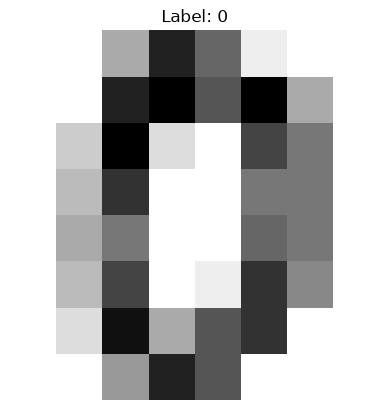

In [17]:
plt.imshow(X[0].reshape(8, 8), cmap='gray_r')
plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

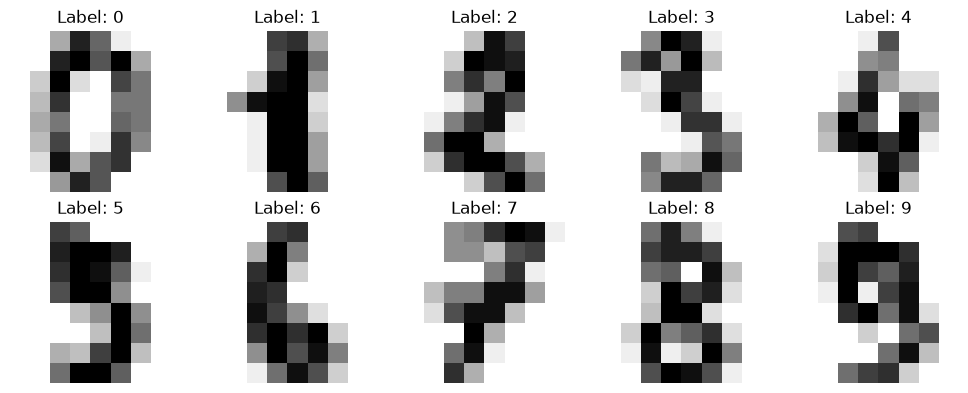

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap='gray_r')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [19]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("Mean after scaling (should be ~0):", X_std.mean(axis=0)[:5])
print("Std after scaling (should be ~1):", X_std.std(axis=0)[:5])

n_samples = X_std.shape[0]
cov_matrix = (X_std.T @ X_std) / (n_samples - 1)

print("Covariance matrix shape:", cov_matrix.shape)
print(cov_matrix[:5, :5])

cov_matrix_np = np.cov(X_std, rowvar=False)
print("Matches np.cov()?", np.allclose(cov_matrix, cov_matrix_np))

Mean after scaling (should be ~0): [ 0.00000000e+00 -2.56086502e-16 -2.34771702e-16 -3.05326777e-16
  1.39689163e-16]
Std after scaling (should be ~1): [0. 1. 1. 1. 1.]
Covariance matrix shape: (64, 64)
[[ 0.          0.          0.          0.          0.        ]
 [ 0.          1.00055679  0.55692803  0.20792922 -0.01877095]
 [ 0.          0.55692803  1.00055679  0.56049216 -0.08428213]
 [ 0.          0.20792922  0.56049216  1.00055679  0.02395166]
 [ 0.         -0.01877095 -0.08428213  0.02395166  1.00055679]]
Matches np.cov()? True


In [20]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("All eigenvalues:")
print(eigenvalues)

All eigenvalues:
[ 7.34477606e+00  5.83549054e+00  5.15396118e+00  3.96623597e+00
  2.96634520e+00  2.57204442e+00  2.40600941e+00  2.06867355e+00
  1.82993314e+00  1.78951739e+00  1.69784616e+00  1.57287889e+00
  1.38870781e+00  1.35933609e+00  1.32152536e+00  1.16829176e+00
  1.08368678e+00  9.99778617e-01  9.74382931e-01  9.08912418e-01
  8.22719264e-01  7.76310139e-01  7.11556753e-01  6.45523648e-01
  5.95273988e-01  5.76501797e-01  5.26731552e-01  5.10636301e-01
  4.86863813e-01  4.55601071e-01  4.42851552e-01  4.22300863e-01
  3.99106303e-01  3.91101111e-01  3.60945168e-01  3.48603059e-01
  3.19596300e-01  2.94066271e-01  2.76922851e-01  2.58273004e-01
  2.47830286e-01  2.42356600e-01  2.17581996e-01  2.07995927e-01
  2.00090902e-01  1.89835165e-01  1.76128942e-01  1.68752359e-01
  1.58184741e-01  1.43114274e-01  1.33210813e-01  1.24263708e-01
  1.19328984e-01  1.11886547e-01  1.02504338e-01  9.84087608e-02
  9.01854301e-02  8.24681230e-02  7.63539426e-02  6.32896150e-02
  5.0374

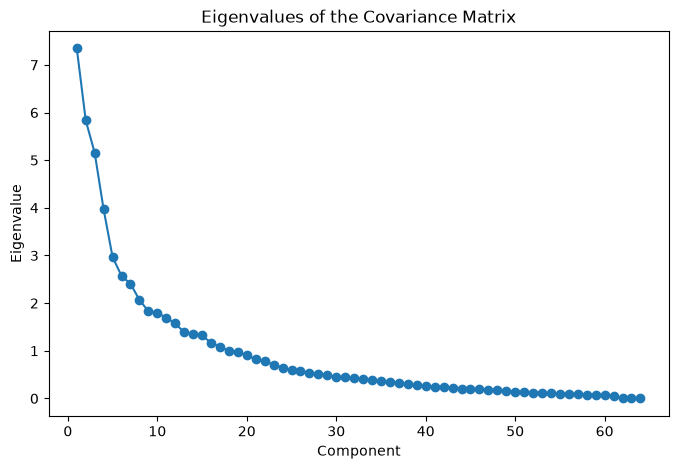

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, marker='o')
plt.title("Eigenvalues of the Covariance Matrix")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.show()

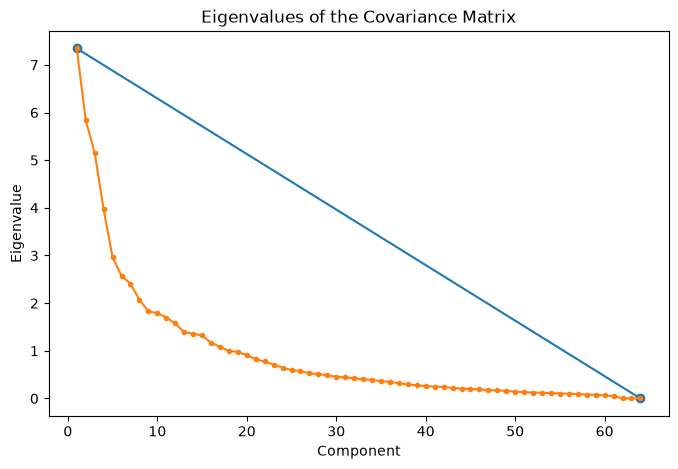

In [22]:
plt.figure(figsize=(8, 5))
plt.plot([1,64],[eigenvalues[0],eigenvalues[-1]], marker='o')
# plt.plot(64, eigenvalues[-1], marker='o')
plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, marker='.')
plt.title("Eigenvalues of the Covariance Matrix")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.show()

In [23]:
"""
Find the point furthest away from the line connecting the first and last eigenvalue.
"""

for i in range(len(eigenvalues)):
    x0, y0 = 1, eigenvalues[0]
    x1, y1 = 64, eigenvalues[-1]
    x2, y2 = i + 1, eigenvalues[i]

    # Calculate the distance from point (x2, y2) to the line (x0, y0) - (x1, y1)
    numerator = abs((y1 - y0) * x2 - (x1 - x0) * y2 + x1 * y0 - y1 * x0)
    denominator = np.sqrt((y1 - y0)**2 + (x1 - x0)**2)
    distance = numerator / denominator

    if i == 0:
        max_distance = distance
        max_index = i
    elif distance > max_distance:
        max_distance = distance
        max_index = i

print(f"Point furthest from the line is at index {max_index} (component {max_index + 1}) with distance {max_distance:.4f}")

Point furthest from the line is at index 8 (component 9) with distance 4.5513


In [24]:
explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained_variance_ratio)

print("Variance explained by top 30 components:")
print(explained_variance_ratio[:30])
print(f"\nCumulative with 2 components: {cumulative[1]*100:.1f}%")
print(f"Cumulative with 3 components: {cumulative[2]*100:.1f}%")
print(f"Cumulative with 10 components: {cumulative[9]*100:.1f}%")
print(f"Cumulative with 15 components: {cumulative[14]*100:.1f}%")
print(f"Cumulative with 30 components: {cumulative[29]*100:.1f}%")

Variance explained by top 30 components:
[0.12033916 0.09561054 0.08444415 0.06498408 0.04860155 0.0421412
 0.03942083 0.03389381 0.02998221 0.02932003 0.02781805 0.02577055
 0.02275303 0.0222718  0.02165229 0.01914167 0.01775547 0.01638069
 0.0159646  0.01489191 0.0134797  0.01271931 0.01165837 0.01057647
 0.00975316 0.00944559 0.00863014 0.00836643 0.00797693 0.00746471]

Cumulative with 2 components: 21.6%
Cumulative with 3 components: 30.0%
Cumulative with 10 components: 58.9%
Cumulative with 15 components: 70.9%
Cumulative with 30 components: 89.3%


In [25]:
"""
helping function
"""

def find_closest_point(A, B, P):
    AB = B - A
    AP = P - A

    t = np.dot(AP, AB) / np.dot(AB, AB)

    closest = A + t * AB

    return tuple(closest)

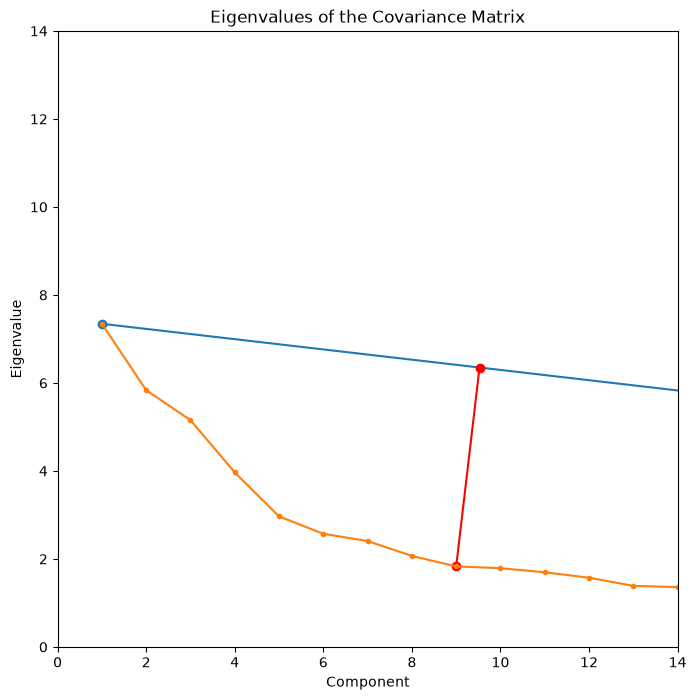

In [26]:
plt.figure(figsize=(8, 8))
plt.plot([1,64],[eigenvalues[0],eigenvalues[-1]], marker='o')
#draw line from point to line
closest_point = find_closest_point(np.array([1, eigenvalues[0]]), np.array([64, eigenvalues[-1]]), np.array([9, eigenvalues[8]]))

plt.plot([9,closest_point[0]], [eigenvalues[8], closest_point[1]], marker='o', color='red', label='Furthest Point')

plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, marker='.')
plt.title("Eigenvalues of the Covariance Matrix")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.xlim(0, 14)
plt.ylim(0, 14)
plt.show()

In [27]:
from kneed import KneeLocator


kneedle = KneeLocator(np.arange(1, len(eigenvalues) + 1), eigenvalues, S=1.0, curve="convex", direction="decreasing")
optimal_components = kneedle.elbow
print(f"Optimal number of components: {optimal_components}")

Optimal number of components: 13


In [28]:
"""
Use the second derivative method
"""

second_derivatives = np.array([])

for i in range(1, len(eigenvalues) - 1):
    second_derivative = eigenvalues[i + 1] - 2 * eigenvalues[i] + eigenvalues[i - 1]
    if second_derivative < 0:
        second_derivatives = np.append(second_derivatives, second_derivative)

argmax_second_derivative = np.argmax(second_derivatives)

print(f"Second derivative method suggests {argmax_second_derivative + 1} components (index {argmax_second_derivative})")

Second derivative method suggests 11 components (index 10)


In [29]:
"""
Kaiser Criterion
"""

eigenvalues_greater_than_one = np.sum(eigenvalues > 1)
print(f"Kaiser Criterion suggests {eigenvalues_greater_than_one} components (eigenvalues greater than 1)")

Kaiser Criterion suggests 17 components (eigenvalues greater than 1)


Reduced data shape: (1797, 17)
Variance kept with 17 components: 74.6%


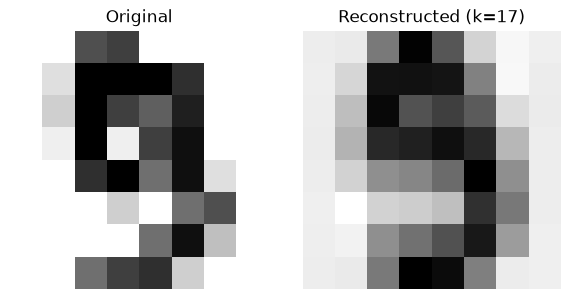

In [36]:
import random

k=17

components = eigenvectors[:,:k]

X_pca = X_std @ components

print("Reduced data shape:", X_pca.shape)
print("Variance kept with", k, "components:", f"{cumulative[k-1]*100:.1f}%")

X_reconstructed_std = X_pca @ components.T     # back to (1797, 64), still standardized
X_reconstructed = scaler.inverse_transform(X_reconstructed_std)  # undo scaling

i = random.randint(0, 9)  # pick an image index to inspect

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(X[i].reshape(8, 8), cmap='gray_r')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(X_reconstructed[i].reshape(8, 8), cmap='gray_r')
axes[1].set_title(f"Reconstructed (k={k})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

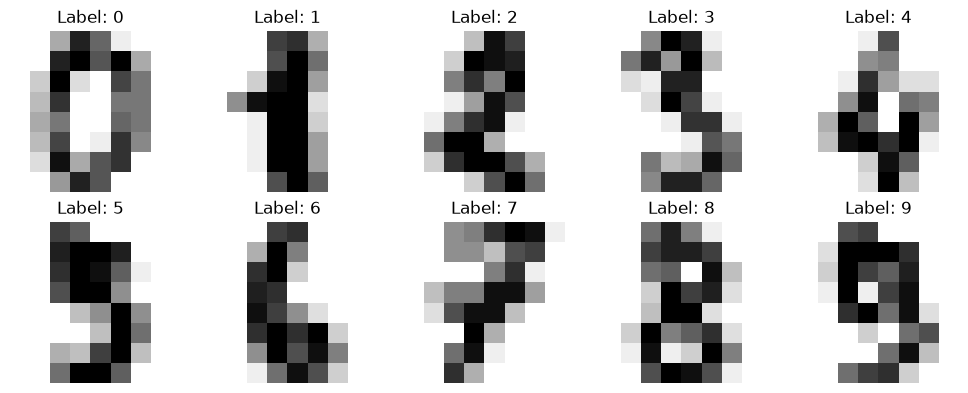

In [31]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap='gray_r')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

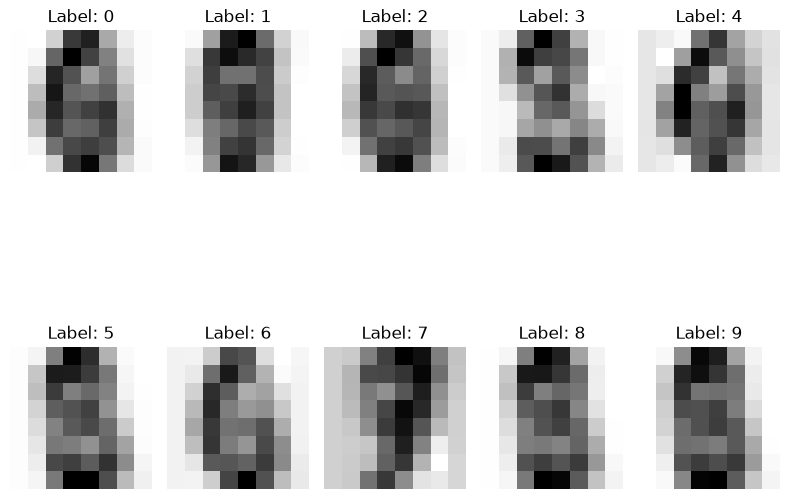

In [32]:
"""
reconstructed
"""

fig, axes = plt.subplots(2, 5, figsize=(8, 8))
for i in range(10):
    axes[i // 5, i % 5].imshow(X_reconstructed[i].reshape(8, 8), cmap='gray_r')
    axes[i // 5, i % 5].set_title(f"Label: {y[i]}")
    axes[i // 5, i % 5].axis('off')

plt.tight_layout()
plt.show()



In [33]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [34]:
model = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(model, X_pca, y, cv=5)  # 5-fold cross-validation

print(f"k={k} components -> CV accuracy: {scores.mean()*100:.1f}% (+/- {scores.std()*100:.1f}%)")

k=2 components -> CV accuracy: 51.4% (+/- 2.5%)


In [35]:
for k_test in [2, 5, 10, 20, 30, 64]:
    components_k = eigenvectors[:, :k_test]
    X_pca_k = X_std @ components_k

    scores = cross_val_score(model, X_pca_k, y, cv=5)
    print(f"k={k_test:3d} -> CV accuracy: {scores.mean()*100:.1f}%  (variance kept: {cumulative[k_test-1]*100:.1f}%)")

k=  2 -> CV accuracy: 51.4%  (variance kept: 21.6%)
k=  5 -> CV accuracy: 84.0%  (variance kept: 41.4%)
k= 10 -> CV accuracy: 89.6%  (variance kept: 58.9%)
k= 20 -> CV accuracy: 93.6%  (variance kept: 79.3%)
k= 30 -> CV accuracy: 94.0%  (variance kept: 89.3%)
k= 64 -> CV accuracy: 94.4%  (variance kept: 100.0%)
